Hamming(7,4) 符号シミュレータ
生成多項式の例     : g(x) = x^3 + x + 1
別の生成多項式例   : g(x) = x^3 + x^2 + 1
注意               : この実装は多項式除算ではなく、パリティビット計算で符号化します。
データビット       : 1101
送信符号語         : 1010101
誤り位置           : 2
受信語             : 1110101
シンドローム       : [0, 1, 0]
シンドローム値     : 2
訂正後             : 1010101


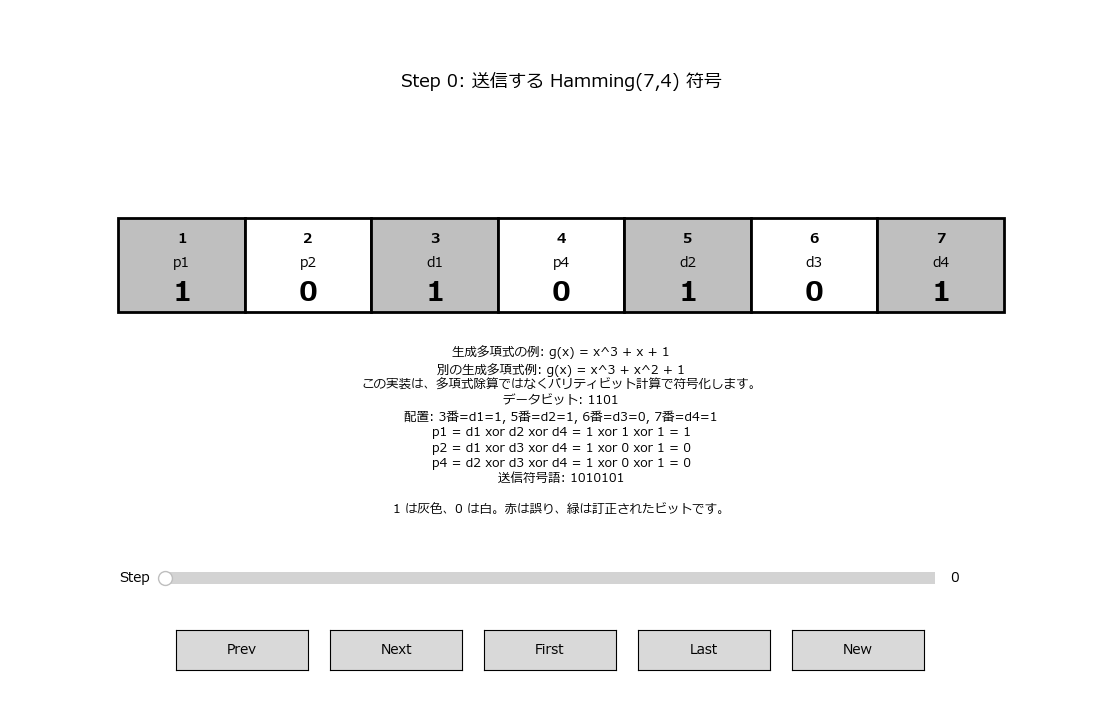

In [3]:
import random
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.widgets import Button, Slider

%matplotlib widget

matplotlib.rcParams["font.family"] = "Meiryo"
matplotlib.rcParams["axes.unicode_minus"] = False

player = None

GENERATOR_POLY_1 = "g(x) = x^3 + x + 1"
GENERATOR_POLY_2 = "g(x) = x^3 + x^2 + 1"


def bits_to_str(bits):
    return "".join(str(b) for b in bits)


def xor_sum(values):
    result = 0
    for v in values:
        result ^= v
    return result


class Hamming74:
    def __init__(self, data_bits=None, error_pos=None):
        if data_bits is None:
            data_bits = [random.randint(0, 1) for _ in range(4)]

        self.data_bits = data_bits[:]
        self.codeword = self.encode(self.data_bits)

        if error_pos is None:
            error_pos = random.randint(1, 7)

        self.error_pos = error_pos

        self.received = self.codeword[:]
        self.before_error_bit = self.received[self.error_pos - 1]
        self.received[self.error_pos - 1] ^= 1
        self.after_error_bit = self.received[self.error_pos - 1]

        self.syndrome_bits, self.syndrome_value = self.calc_syndrome(self.received)

        self.corrected = self.received[:]
        self.before_correct_bit = self.corrected[self.syndrome_value - 1]
        self.corrected[self.syndrome_value - 1] ^= 1
        self.after_correct_bit = self.corrected[self.syndrome_value - 1]

    def encode(self, data):
        d1, d2, d3, d4 = data

        code = [0] * 7

        code[2] = d1
        code[4] = d2
        code[5] = d3
        code[6] = d4

        self.p1 = xor_sum([code[2], code[4], code[6]])
        self.p2 = xor_sum([code[2], code[5], code[6]])
        self.p4 = xor_sum([code[4], code[5], code[6]])

        code[0] = self.p1
        code[1] = self.p2
        code[3] = self.p4

        return code

    def calc_syndrome(self, bits):
        s1 = xor_sum([bits[0], bits[2], bits[4], bits[6]])
        s2 = xor_sum([bits[1], bits[2], bits[5], bits[6]])
        s4 = xor_sum([bits[3], bits[4], bits[5], bits[6]])

        syndrome_value = s1 * 1 + s2 * 2 + s4 * 4
        return [s1, s2, s4], syndrome_value

    def parity_explanation(self):
        d1, d2, d3, d4 = self.data_bits
        return (
            f"配置: 3番=d1={d1}, 5番=d2={d2}, 6番=d3={d3}, 7番=d4={d4}\n"
            f"p1 = d1 xor d2 xor d4 = {d1} xor {d2} xor {d4} = {self.p1}\n"
            f"p2 = d1 xor d3 xor d4 = {d1} xor {d3} xor {d4} = {self.p2}\n"
            f"p4 = d2 xor d3 xor d4 = {d2} xor {d3} xor {d4} = {self.p4}"
        )

    def syndrome_explanation(self):
        b = self.received
        s1, s2, s4 = self.syndrome_bits
        return (
            f"s1 = bit1 xor bit3 xor bit5 xor bit7 = "
            f"{b[0]} xor {b[2]} xor {b[4]} xor {b[6]} = {s1}\n"
            f"s2 = bit2 xor bit3 xor bit6 xor bit7 = "
            f"{b[1]} xor {b[2]} xor {b[5]} xor {b[6]} = {s2}\n"
            f"s4 = bit4 xor bit5 xor bit6 xor bit7 = "
            f"{b[3]} xor {b[4]} xor {b[5]} xor {b[6]} = {s4}\n"
            f"誤り位置 = s1*1 + s2*2 + s4*4 = "
            f"{s1}*1 + {s2}*2 + {s4}*4 = {self.syndrome_value}"
        )


def draw_bits(
    ax,
    bits,
    title,
    highlight_pos=None,
    corrected_pos=None,
    syndrome_groups=None,
    explanation=""
):
    ax.clear()

    labels = ["p1", "p2", "d1", "p4", "d2", "d3", "d4"]

    for i, bit in enumerate(bits):
        pos = i + 1

        face = "#BFBFBF" if bit == 1 else "white"
        if highlight_pos == pos:
            face = "#FFCCCC"
        if corrected_pos == pos:
            face = "#CCFFCC"

        rect = Rectangle(
            (i, 0),
            1,
            1,
            facecolor=face,
            edgecolor="black",
            linewidth=2
        )
        ax.add_patch(rect)

        ax.text(i + 0.5, 0.78, f"{pos}",
                ha="center", va="center",
                fontsize=10, fontweight="bold")

        ax.text(i + 0.5, 0.52, labels[i],
                ha="center", va="center",
                fontsize=10)

        ax.text(i + 0.5, 0.20, str(bit),
                ha="center", va="center",
                fontsize=20, fontweight="bold")

    if syndrome_groups is not None:
        y = 1.25
        for name, group in syndrome_groups:
            xs = [p - 0.5 for p in group]

            ax.plot(
                xs,
                [y] * len(xs),
                marker="o",
                linestyle="-",
                linewidth=2
            )

            ax.text(
                sum(xs) / len(xs),
                y + 0.12,
                name,
                ha="center",
                fontsize=10
            )

            y += 0.35

    ax.text(
        3.5,
        -0.35,
        explanation,
        ha="center",
        va="top",
        fontsize=9,
        linespacing=1.35
    )

    ax.text(
        3.5,
        -2.15,
        "1 は灰色、0 は白。赤は誤り、緑は訂正されたビットです。",
        ha="center",
        fontsize=9
    )

    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(-2.35, 2.25)
    ax.axis("off")
    ax.set_title(title, fontsize=13, pad=10)


class HammingPlayer:
    def __init__(self, hamming):
        self.h = hamming
        self.index = 0
        self.steps = self.make_steps()

        self.fig, self.ax = plt.subplots(figsize=(11, 7.2))

        plt.subplots_adjust(
            left=0.05,
            right=0.97,
            top=0.86,
            bottom=0.26
        )

        ax_slider = plt.axes([0.15, 0.18, 0.70, 0.035])

        ax_prev = plt.axes([0.16, 0.07, 0.12, 0.055])
        ax_next = plt.axes([0.30, 0.07, 0.12, 0.055])
        ax_first = plt.axes([0.44, 0.07, 0.12, 0.055])
        ax_last = plt.axes([0.58, 0.07, 0.12, 0.055])
        ax_new = plt.axes([0.72, 0.07, 0.12, 0.055])

        self.btn_prev = Button(ax_prev, "Prev")
        self.btn_next = Button(ax_next, "Next")
        self.btn_first = Button(ax_first, "First")
        self.btn_last = Button(ax_last, "Last")
        self.btn_new = Button(ax_new, "New")

        self.btn_prev.on_clicked(self.on_prev)
        self.btn_next.on_clicked(self.on_next)
        self.btn_first.on_clicked(self.on_first)
        self.btn_last.on_clicked(self.on_last)
        self.btn_new.on_clicked(self.on_new)

        self.slider = Slider(
            ax_slider,
            "Step",
            0,
            len(self.steps) - 1,
            valinit=0,
            valstep=1
        )
        self.slider.on_changed(self.on_slider)

        self.draw()

    def make_steps(self):
        h = self.h

        groups = [
            ("s1 = 1,3,5,7", [1, 3, 5, 7]),
            ("s2 = 2,3,6,7", [2, 3, 6, 7]),
            ("s4 = 4,5,6,7", [4, 5, 6, 7]),
        ]

        poly_text = (
            f"生成多項式の例: {GENERATOR_POLY_1}\n"
            f"別の生成多項式例: {GENERATOR_POLY_2}\n"
            "この実装は、多項式除算ではなくパリティビット計算で符号化します。"
        )

        return [
            {
                "bits": h.codeword,
                "title": "Step 0: 送信する Hamming(7,4) 符号",
                "highlight_pos": None,
                "corrected_pos": None,
                "syndrome_groups": None,
                "explanation": (
                    f"{poly_text}\n"
                    f"データビット: {bits_to_str(h.data_bits)}\n"
                    f"{h.parity_explanation()}\n"
                    f"送信符号語: {bits_to_str(h.codeword)}"
                )
            },
            {
                "bits": h.received,
                "title": "Step 1: 1ビット誤りが発生",
                "highlight_pos": h.error_pos,
                "corrected_pos": None,
                "syndrome_groups": None,
                "explanation": (
                    f"{h.error_pos} 番目のビットが反転しました。\n"
                    f"反転前: {h.before_error_bit} → 反転後: {h.after_error_bit}\n"
                    f"送信符号語: {bits_to_str(h.codeword)}\n"
                    f"受信語:     {bits_to_str(h.received)}"
                )
            },
            {
                "bits": h.received,
                "title": "Step 2: シンドロームを計算",
                "highlight_pos": h.error_pos,
                "corrected_pos": None,
                "syndrome_groups": groups,
                "explanation": h.syndrome_explanation()
            },
            {
                "bits": h.received,
                "title": "Step 3: 誤り位置を特定",
                "highlight_pos": h.syndrome_value,
                "corrected_pos": None,
                "syndrome_groups": groups,
                "explanation": (
                    f"シンドローム bits = {h.syndrome_bits}\n"
                    f"シンドローム値 = {h.syndrome_value}\n"
                    f"これは {h.syndrome_value} 番目のビットが誤りであることを示します。"
                )
            },
            {
                "bits": h.corrected,
                "title": "Step 4: 誤りを訂正",
                "highlight_pos": None,
                "corrected_pos": h.syndrome_value,
                "syndrome_groups": None,
                "explanation": (
                    f"{h.syndrome_value} 番目を反転して訂正します。\n"
                    f"訂正前: {h.before_correct_bit} → 訂正後: {h.after_correct_bit}\n"
                    f"受信語:     {bits_to_str(h.received)}\n"
                    f"訂正後:     {bits_to_str(h.corrected)}\n"
                    f"元の符号語: {bits_to_str(h.codeword)}"
                )
            },
        ]

    def draw(self):
        step = self.steps[self.index]

        draw_bits(
            self.ax,
            bits=step["bits"],
            title=step["title"],
            highlight_pos=step["highlight_pos"],
            corrected_pos=step["corrected_pos"],
            syndrome_groups=step["syndrome_groups"],
            explanation=step["explanation"]
        )

        self.fig.canvas.draw_idle()

    def set_index(self, idx):
        self.index = max(0, min(int(idx), len(self.steps) - 1))

        self.slider.eventson = False
        self.slider.set_val(self.index)
        self.slider.eventson = True

        self.draw()

    def on_prev(self, event):
        self.set_index(self.index - 1)

    def on_next(self, event):
        self.set_index(self.index + 1)

    def on_first(self, event):
        self.set_index(0)

    def on_last(self, event):
        self.set_index(len(self.steps) - 1)

    def on_new(self, event):
        self.h = Hamming74()
        self.steps = self.make_steps()
        self.set_index(0)
        self.print_summary("新しい Hamming(7,4) 符号")

    def on_slider(self, value):
        self.set_index(int(value))

    def print_summary(self, header):
        print("\n" + "=" * 70)
        print(header)
        print("=" * 70)
        print("生成多項式の例     :", GENERATOR_POLY_1)
        print("別の生成多項式例   :", GENERATOR_POLY_2)
        print("データビット       :", bits_to_str(self.h.data_bits))
        print("送信符号語         :", bits_to_str(self.h.codeword))
        print("誤り位置           :", self.h.error_pos)
        print("受信語             :", bits_to_str(self.h.received))
        print("シンドローム       :", self.h.syndrome_bits)
        print("シンドローム値     :", self.h.syndrome_value)
        print("訂正後             :", bits_to_str(self.h.corrected))


def main():
    global player

    h = Hamming74()

    print("=" * 70)
    print("Hamming(7,4) 符号シミュレータ")
    print("=" * 70)
    print("生成多項式の例     :", GENERATOR_POLY_1)
    print("別の生成多項式例   :", GENERATOR_POLY_2)
    print("注意               : この実装は多項式除算ではなく、パリティビット計算で符号化します。")
    print("データビット       :", bits_to_str(h.data_bits))
    print("送信符号語         :", bits_to_str(h.codeword))
    print("誤り位置           :", h.error_pos)
    print("受信語             :", bits_to_str(h.received))
    print("シンドローム       :", h.syndrome_bits)
    print("シンドローム値     :", h.syndrome_value)
    print("訂正後             :", bits_to_str(h.corrected))

    player = HammingPlayer(h)
    plt.show()


if __name__ == "__main__":
    main()